In [1]:
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from pathlib import Path
from numpy.lib.stride_tricks import sliding_window_view
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    classification_report
)

warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')

PyTorch: 2.12.0+cu132
CUDA disponible: True


In [2]:
BASE_DATA_DIR = '../data'
OUTPUT_DIR = '../data/processed'
MODELS_DIR = '../models'
RESULTS_DIR = '../results'

SEQ_LEN = 4              # Minimo de horas reales requeridas por estancia
MAX_SEQ_LEN = 24         # Contexto maximo que puede ver el modelo (ventana variable)
PREDICTION_HORIZON_H = 6 # Predice onset en las proximas 6 horas
MIN_HOURS = SEQ_LEN      # Minimo de horas con datos para incluir estancia

# Hiperparametros
BATCH_SIZE = 256
EPOCHS = 150
LR = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.4
PATIENCE = 25
WARMUP_EPOCHS = 5
LAMBDA_SOFA = 0.2        # Peso de la tarea auxiliar SOFA (multi-task)

RANDOM_STATE_SEED = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'SEQ_LEN (minimo): {SEQ_LEN}h  |  MAX_SEQ_LEN (contexto maximo): {MAX_SEQ_LEN}h')
print(f'HIDDEN_SIZE: {HIDDEN_SIZE}  |  NUM_LAYERS: {NUM_LAYERS}  |  LAMBDA_SOFA: {LAMBDA_SOFA}')

# Fijar semillas de PyTorch para reproducibilidad determinista
torch.manual_seed(RANDOM_STATE_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print('Semillas PyTorch fijadas (deterministico)')

Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)


Dispositivo: cuda
SEQ_LEN (minimo): 4h  |  MAX_SEQ_LEN (contexto maximo): 24h
HIDDEN_SIZE: 64  |  NUM_LAYERS: 1  |  LAMBDA_SOFA: 0.2
Semillas PyTorch fijadas (deterministico)


In [3]:
features_df = pd.read_parquet(f'{OUTPUT_DIR}/features_df.parquet')
cohort_df = pd.read_parquet(f'{OUTPUT_DIR}/cohort_df.parquet')

FEATURE_COLS = [
    col for col in features_df.columns
    if col not in ['stay_id', 'hour_bucket', 'Bands'] # Quitamos Bands por 99.7% NaN
]

N_FEATURES = len(FEATURE_COLS)

# Convierte str a datetime
cohort_df['intime'] = pd.to_datetime(cohort_df['intime'])
cohort_df['sepsis_onset'] = pd.to_datetime(cohort_df['sepsis_onset'])

# Calcular onset_h: Horas desde intime hasta el onset (solo para sepsis)
cohort_df['onset_h'] = np.where(
    cohort_df['label'] == 1,
    (cohort_df['sepsis_onset'] - cohort_df['intime']).dt.total_seconds() / 3600,
    np.nan
)

# Mapeamos las horas por estancia y el resultado (sepsis / no sepsis)
ONSET_H_MAP = cohort_df.set_index('stay_id')['onset_h'].to_dict()
LABEL_MAP = cohort_df.set_index('stay_id')['label'].to_dict()

# Cargar SOFA horario para target auxiliar de multi-task 
sofa_hourly = pd.read_parquet(f'{OUTPUT_DIR}/sofa_hourly.parquet')
sofa_hourly['hour_bucket'] = sofa_hourly['h_since_intime'].astype(int)
print(f'SOFA HOURLY: {len(sofa_hourly)}')

# Lookup (stay_id, hour_bucket) - SOFA. Para controles devolvera NaN
SOFA_LOOKUP = sofa_hourly.set_index(['stay_id', 'hour_bucket'])['sofa'].to_dict()

print(f'Estancias totales: {cohort_df["stay_id"].nunique():,}')
print(f'    Sepsis (label = 1): {(cohort_df["label"] == 1).sum():,}')
print(f'    Control (label = 0): {(cohort_df["label"] == 0).sum():,}')
print()
print(f'Features ({N_FEATURES}): {FEATURE_COLS}')

SOFA HOURLY: 5203081
Estancias totales: 74,754
    Sepsis (label = 1): 37,377
    Control (label = 0): 37,377

Features (26): ['Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Temperature Celsius', 'Bicarbonate', 'Bilirubin, Total', 'Creatinine', 'Glucose', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'White Blood Cells', 'pH', 'pO2', 'urine_output_ml', 'vasopressor_active', 'mechanical_ventilation', 'age', 'gender_enc', 'charlson_score']


In [4]:
stays_coverage = features_df.groupby('stay_id')['hour_bucket'].count()
valid_stay_ids = stays_coverage[stays_coverage >= MIN_HOURS].index

stay_labels_v = cohort_df[cohort_df['stay_id'].isin(valid_stay_ids)][
    ['stay_id', 'label', 'subject_id']
].reset_index(drop=True)

all_stays = stay_labels_v['stay_id'].values
all_labels = stay_labels_v['label'].values
all_subjects = stay_labels_v['subject_id'].values

first_shuffle_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE_SEED)
tv_idx, test_idx = next(
    first_shuffle_split.split(all_stays, all_labels, groups=all_subjects)
)

second_shuffle_split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE_SEED)
tr_idx, val_idx = next(
    second_shuffle_split.split(all_stays[tv_idx], all_labels[tv_idx], groups=all_subjects[tv_idx])
)

train_stays = all_stays[tv_idx][tr_idx]
val_stays = all_stays[tv_idx][val_idx]
test_stays = all_stays[test_idx]

stay_to_subject = cohort_df.set_index('stay_id')['subject_id']
train_sub = set(stay_to_subject[stay_to_subject.index.isin(train_stays)])
val_sub = set(stay_to_subject[stay_to_subject.index.isin(val_stays)])
test_sub = set(stay_to_subject[stay_to_subject.index.isin(test_stays)])

print(f'Train: {len(train_stays):,} estancias | {len(train_sub):,} pacientes')
print(f'Validation: {len(val_stays):,} estancias | {len(val_sub):,} pacientes')
print(f'Test: {len(test_stays):,} estancias | {len(test_sub):,} pacientes')

Train: 44,794 estancias | 32,220 pacientes
Validation: 14,889 estancias | 10,740 pacientes
Test: 14,871 estancias | 10,740 pacientes


In [5]:
def build_sequences(
    features_df,
    stay_ids,
    feature_cols,
    onset_h_map,
    label_map,
    sofa_lookup=None,
    max_seq_len=MAX_SEQ_LEN,
    seq_len=SEQ_LEN,
    horizon_h=PREDICTION_HORIZON_H,
):
    """
    Genera secuencias de longitud VARIABLE para prediccion rodante.

    Cada ventana termina en end_hour y toma hasta max_seq_len horas de historia.
    Las horas anteriores al inicio de la estancia se rellenan con NaN (left-padding),
    de modo que el modelo opera con el contexto disponible en cada momento sin
    excluir pacientes por tener historia insuficiente.

    Retorna:
        X       : (n, max_seq_len, F)  — left-padded con NaN donde no hay historia
        y       : (n,)
        sids    : (n,)
        leads   : (n,)
        sofa    : (n,)
        lengths : (n,)  — numero real de horas en cada ventana (1..max_seq_len)
    """
    F = len(feature_cols)
    features_grouped_by_stay = dict(tuple(
        features_df[features_df['stay_id'].isin(stay_ids)].groupby('stay_id')
    ))

    X_list, y_list, sid_list, lead_list, sofa_list, len_list = [], [], [], [], [], []

    for stay_id in stay_ids:
        if stay_id not in features_grouped_by_stay:
            continue

        df_s = features_grouped_by_stay[stay_id].sort_values('hour_bucket')
        is_sepsis = label_map.get(stay_id, 0)
        onset_hour = onset_h_map.get(stay_id)

        MIN_ONSET_H = 6
        if is_sepsis and onset_hour is not None and not pd.isna(onset_hour) and onset_hour < MIN_ONSET_H:
            continue

        CONTROL_MAX_LOS_H = 168
        if is_sepsis and onset_hour is not None and not pd.isna(onset_hour):
            max_hour = int(onset_hour) - 1
        else:
            max_hour = min(int(df_s['hour_bucket'].max()), CONTROL_MAX_LOS_H - 1)

        df_s = df_s[df_s['hour_bucket'].between(0, max_hour)]
        if df_s['hour_bucket'].nunique() < seq_len:
            continue

        # Grid denso con NaN donde no hay medicion
        grid = np.full((max_hour + 1, F), np.nan, dtype=np.float32)
        hb_vals = df_s['hour_bucket'].astype(int).values
        feat_vals = df_s[feature_cols].values.astype(np.float32)
        valid_mask = (hb_vals >= 0) & (hb_vals <= max_hour)
        grid[hb_vals[valid_mask]] = feat_vals[valid_mask]

        num_hours = max_hour + 1
        num_windows = num_hours

        # Left-pad el grid con max_seq_len-1 NaN al inicio.
        # sliding_window_view sobre el grid paddeado genera num_hours ventanas:
        #   - ventana i tiene end_hour=i y real_len=min(i+1, max_seq_len)
        #   - las posiciones [0 : max_seq_len - real_len] son NaN (padding)
        #   - las posiciones [max_seq_len - real_len : max_seq_len] son datos reales
        padded = np.full((max_seq_len - 1 + num_hours, F), np.nan, dtype=np.float32)
        padded[max_seq_len - 1:] = grid

        windows = sliding_window_view(padded, (max_seq_len, F)).reshape(-1, max_seq_len, F)
        lengths_arr = np.minimum(np.arange(1, num_windows + 1, dtype=np.int64), max_seq_len)
        end_hour = np.arange(num_windows, dtype=np.float32)

        # Etiquetas rodantes
        if is_sepsis and onset_hour is not None and not pd.isna(onset_hour):
            hour_to_onset = float(onset_hour) - end_hour
            labels = ((hour_to_onset > 0) & (hour_to_onset <= horizon_h)).astype(np.float32)
            leads = hour_to_onset
        else:
            labels = np.zeros(num_windows, dtype=np.float32)
            leads = np.full(num_windows, np.nan, dtype=np.float32)

        # Subsampling para controles
        MAX_WINDOWS_PER_CONTROL = 30
        if not is_sepsis and num_windows > MAX_WINDOWS_PER_CONTROL:
            keep_idx = np.linspace(0, num_windows - 1, MAX_WINDOWS_PER_CONTROL).astype(int)
            windows = windows[keep_idx]
            labels = labels[keep_idx]
            leads = leads[keep_idx]
            lengths_arr = lengths_arr[keep_idx]
            end_hour = end_hour[keep_idx]

        if sofa_lookup is not None:
            sofa_window = np.array(
                [sofa_lookup.get((stay_id, int(h)), np.nan) for h in end_hour],
                dtype=np.float32
            )
        else:
            sofa_window = np.full(len(windows), np.nan, dtype=np.float32)

        X_list.append(windows)
        y_list.append(labels)
        sid_list.extend([stay_id] * len(windows))
        lead_list.append(leads)
        sofa_list.append(sofa_window)
        len_list.append(lengths_arr)

    if not X_list:
        empty = np.empty((0, max_seq_len, F), dtype=np.float32)
        return empty, np.array([]), np.array([]), np.array([]), np.array([]), np.array([], dtype=np.int64)

    return (
        np.concatenate(X_list, axis=0),
        np.concatenate(y_list, axis=0),
        np.array(sid_list),
        np.concatenate(lead_list, axis=0),
        np.concatenate(sofa_list, axis=0),
        np.concatenate(len_list, axis=0),
    )


In [6]:
X_train, y_train, sids_train, leads_train, sofa_train, lens_train = build_sequences(
    features_df=features_df,
    stay_ids=train_stays,
    feature_cols=FEATURE_COLS,
    onset_h_map=ONSET_H_MAP,
    label_map=LABEL_MAP,
    sofa_lookup=SOFA_LOOKUP,
)
X_val, y_val, sids_val, leads_val, sofa_val, lens_val = build_sequences(
    features_df=features_df,
    stay_ids=val_stays,
    feature_cols=FEATURE_COLS,
    onset_h_map=ONSET_H_MAP,
    label_map=LABEL_MAP,
    sofa_lookup=SOFA_LOOKUP,
)
X_test, y_test, sids_test, leads_test, sofa_test, lens_test = build_sequences(
    features_df=features_df,
    stay_ids=test_stays,
    feature_cols=FEATURE_COLS,
    onset_h_map=ONSET_H_MAP,
    label_map=LABEL_MAP,
    sofa_lookup=SOFA_LOOKUP,
)

print(f'X_train: {X_train.shape} | positivos: {y_train.mean():.2%} | len media: {lens_train.mean():.1f}h')
print(f'X_val:   {X_val.shape}   | positivos: {y_val.mean():.2%} | len media: {lens_val.mean():.1f}h')
print(f'X_test:  {X_test.shape}  | positivos: {y_test.mean():.2%} | len media: {lens_test.mean():.1f}h')


X_train: (759894, 24, 26) | positivos: 5.05% | len media: 16.5h
X_val:   (252310, 24, 26)   | positivos: 5.09% | len media: 16.5h
X_test:  (252116, 24, 26)  | positivos: 4.90% | len media: 16.6h


In [7]:
# Subsampling estratificado de negativos en train (ratio 5:1 neg:pos)
# Val/test se dejan completos para preservar la prevalencia real en metricas
NEG_POS_RATIO = 10
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
n_neg_keep = min(len(neg_idx), len(pos_idx) * NEG_POS_RATIO)
_rng = np.random.default_rng(RANDOM_STATE_SEED)
neg_keep = _rng.choice(neg_idx, size=n_neg_keep, replace=False)
keep = np.sort(np.concatenate([pos_idx, neg_keep]))
X_train     = X_train[keep]
y_train     = y_train[keep]
sids_train  = sids_train[keep]
leads_train = leads_train[keep]
sofa_train  = sofa_train[keep]
lens_train  = lens_train[keep]
print(f'Tras subsampling — X_train: {X_train.shape} | positivos: {y_train.mean():.2%}')


Tras subsampling — X_train: (422070, 24, 26) | positivos: 9.09%


In [8]:
def apply_forward_fill_vectorized(X, max_gap=24):
    """
    Forward fill vectorizado sobre el eje temporal (axis=1) con tope de propagación.

    max_gap: máximo de horas que un valor puede propagarse hacia adelante antes
    de volver a NaN (por defecto 24h). Evita arrastrar labs medidos hace varios
    días como si fueran actuales.
    """
    n, T, F = X.shape
    X_ff = X.copy()
    arange_T = np.arange(T)
    for j in range(F):
        arr  = X_ff[:, :, j]                          # (n, T)
        mask = ~np.isnan(arr)                          # True donde hay valor real
        idx  = np.where(mask, arange_T, 0)            # índice del último válido, o 0
        np.maximum.accumulate(idx, axis=1, out=idx)   # propagar último índice válido
        gap  = arange_T[None, :] - idx                # distancia (horas) al último valor real
        filled = arr[np.arange(n)[:, None], idx]
        # Si el gap supera max_gap, el valor propagado se descarta (vuelve a NaN)
        too_old = gap > max_gap
        filled = np.where(too_old, np.nan, filled)
        X_ff[:, :, j] = filled
    return X_ff


# Calcular máscaras ANTES del forward fill (refleja mediciones reales)
M_train = (~np.isnan(X_train)).astype(np.float32)
M_val   = (~np.isnan(X_val)).astype(np.float32)
M_test  = (~np.isnan(X_test)).astype(np.float32)

X_train_ff = apply_forward_fill_vectorized(X_train)
X_val_ff   = apply_forward_fill_vectorized(X_val)
X_test_ff  = apply_forward_fill_vectorized(X_test)

pct_nan_antes   = np.isnan(X_train).mean()
pct_nan_despues = np.isnan(X_train_ff).mean()
print(f'NaN antes del ffill:   {pct_nan_antes:.1%}')
print(f'NaN despues del ffill: {pct_nan_despues:.1%}')

NaN antes del ffill:   70.3%
NaN despues del ffill: 51.7%


In [9]:
def compute_deltas(X_ff, M_original=None):
    """
    Diferencias temporales (deltas) sobre features forward-filleadas.

    delta[t] = X_ff[t] - X_ff[t-1]  para t > 0, delta[0] = 0.
    Los NaN en la diferencia (alguno de los dos timesteps sin valor tras ffill)
    se sustituyen por 0 antes de aplicar la mascara, ya que en numpy NaN*0 = NaN
    y propagaria NaN al LSTM.
    Si se proporciona M_original, el delta se anula cuando alguno de los dos
    timesteps consecutivos no tuvo medicion real.
    """
    deltas = np.zeros_like(X_ff)
    diff = X_ff[:, 1:, :] - X_ff[:, :-1, :]
    # NaN en la diferencia → 0 (evita NaN * 0 = NaN al enmascarar)
    deltas[:, 1:, :] = np.where(np.isnan(diff), 0.0, diff)

    if M_original is not None:
        # Delta valido solo si t-1 y t tienen medicion real
        both_measured = M_original[:, 1:, :] * M_original[:, :-1, :]
        deltas[:, 1:, :] *= both_measured

    return deltas.astype(np.float32)


deltas_train = compute_deltas(X_train_ff, M_train)
deltas_val   = compute_deltas(X_val_ff,   M_val)
deltas_test  = compute_deltas(X_test_ff,  M_test)

nonzero_pct = (deltas_train != 0).mean()
print(f'Deltas train shape: {deltas_train.shape}')
print(f'Deltas no nulos (cambios reales medidos): {nonzero_pct:.2%}')
print(f'NaN en deltas_train: {np.isnan(deltas_train).sum()}')


Deltas train shape: (422070, 24, 26)
Deltas no nulos (cambios reales medidos): 9.76%
NaN en deltas_train: 0


In [10]:
def apply_missingness_mask(X, train_medians=None, external_mask=None, external_deltas=None):
    """
    Estrategia de imputación con missingness mask y deltas opcionales:
    1. Construye máscara binaria M: 1 = valor real, 0 = imputado.
    2. Rellena NaN con la mediana global del training (valor neutro).
    3. Concatena [X_imputed | deltas | M] → shape (n, T, 3*F) si se pasan deltas,
       o [X_imputed | M] → shape (n, T, 2*F) si no.

    external_mask: máscara pre-computada desde el tensor original con NaN.
    external_deltas: deltas pre-computados desde apply_forward_fill (opcional).
    """

    _, _, F = X.shape

    M = external_mask if external_mask is not None else (~np.isnan(X)).astype(np.float32)

    X_imp = X.copy()

    if train_medians is None:
        flat = X_imp.reshape(-1, F)
        train_medians = np.nanmedian(flat, axis=0)
        train_medians = np.where(np.isnan(train_medians), 0.0, train_medians)

    for j in range(F):
        mask_nan = np.isnan(X_imp[:, :, j])
        X_imp[:, :, j][mask_nan] = train_medians[j]

    parts = [X_imp]
    if external_deltas is not None:
        parts.append(external_deltas)
    parts.append(M)

    X_out = np.concatenate(parts, axis=2).astype(np.float32)
    return X_out, train_medians


X_train_masked, train_medians = apply_missingness_mask(
    X_train_ff, external_mask=M_train, external_deltas=deltas_train
)
X_val_masked, _ = apply_missingness_mask(
    X_val_ff, train_medians, external_mask=M_val, external_deltas=deltas_val
)
X_test_masked, _ = apply_missingness_mask(
    X_test_ff, train_medians, external_mask=M_test, external_deltas=deltas_test
)

print(f'Shape tras aplicar mask + deltas: {X_train_masked.shape} → input_size al LSTM: {X_train_masked.shape[2]}')


Shape tras aplicar mask + deltas: (422070, 24, 78) → input_size al LSTM: 78


In [11]:
# Estructura del tensor: [valores (F) | deltas (F) | mascaras (F)] → F_total = 3*F
# Solo valores y deltas se normalizan; las mascaras ya son binarias {0,1}
n_tr, T, F_total = X_train_masked.shape
F = F_total // 3

scaler = StandardScaler()

def scale_masked(X, scaler, F, fit=False):
    n, T, F_total = X.shape
    has_deltas = (F_total == 3 * F)

    X_vals = X[:, :, :F].reshape(-1, F)
    if fit:
        X_vals_scaled = scaler.fit_transform(X_vals)
    else:
        X_vals_scaled = scaler.transform(X_vals)
    X_vals_scaled = X_vals_scaled.reshape(n, T, F).astype(np.float32)

    if has_deltas:
        # Deltas se normalizan solo por la desviacion estandar (no se resta media:
        # delta=0 significa "sin cambio" y debe mapearse a 0 tras normalizacion)
        delta_std = np.where(scaler.scale_ > 0, scaler.scale_, 1.0)
        X_deltas = X[:, :, F:2*F].reshape(-1, F)
        X_deltas_scaled = (X_deltas / delta_std).reshape(n, T, F).astype(np.float32)
        X_mask = X[:, :, 2*F:]
        return np.concatenate([X_vals_scaled, X_deltas_scaled, X_mask], axis=2).astype(np.float32)
    else:
        X_mask = X[:, :, F:]
        return np.concatenate([X_vals_scaled, X_mask], axis=2).astype(np.float32)


X_train_norm = scale_masked(X_train_masked, scaler, F, fit=True)
X_val_norm   = scale_masked(X_val_masked,   scaler, F, fit=False)
X_test_norm  = scale_masked(X_test_masked,  scaler, F, fit=False)

N_INPUT = X_train_norm.shape[2]  # 3*F = valores + deltas + mascaras
print(f'Input al LSTM: {N_INPUT}  (shape: {X_train_norm.shape})')
print(f'  {F} valores normalizados | {F} deltas normalizados | {F} mascaras binarias')
print(f'Mascaras — rango: [{X_train_norm[:,:,2*F:].min():.0f}, {X_train_norm[:,:,2*F:].max():.0f}]')


Input al LSTM: 78  (shape: (422070, 24, 78))
  26 valores normalizados | 26 deltas normalizados | 26 mascaras binarias
Mascaras — rango: [0, 1]


In [12]:
class SepsisDataset(Dataset):
    """Dataset que devuelve (X, y, length, sofa) por ventana."""
    def __init__(self, X, y, lengths, sofa):
        self.X       = torch.from_numpy(X).float()
        self.y       = torch.from_numpy(y).float()
        self.lengths = torch.from_numpy(lengths).long()
        self.sofa    = torch.from_numpy(sofa).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx], self.sofa[idx]


train_ds = SepsisDataset(X_train_norm, y_train, lens_train, sofa_train)
val_ds   = SepsisDataset(X_val_norm,   y_val,   lens_val,   sofa_val)
test_ds  = SepsisDataset(X_test_norm,  y_test,  lens_test,  sofa_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight_val = n_neg / max(n_pos, 1)

N_INPUT = X_train_norm.shape[2]
sofa_obs = int(np.sum(~np.isnan(sofa_train)))
print(f'Input shape: {X_train_norm.shape} → N_INPUT: {N_INPUT}')
print(f'Train batches: {len(train_loader)} x {BATCH_SIZE}')
print(f'Positivos: {n_pos:,} ({n_pos/len(y_train):.1%}) | Negativos: {n_neg:,}')
print(f'Ventanas con SOFA conocido (train): {sofa_obs:,} ({sofa_obs/len(sofa_train):.1%})')


Input shape: (422070, 24, 78) → N_INPUT: 78
Train batches: 1648 x 256
Positivos: 38,370 (9.1%) | Negativos: 383,700
Ventanas con SOFA conocido (train): 164,153 (38.9%)


In [13]:
class Bi_LSTM_Sepsis(nn.Module):
    """BiLSTM con atencion enmascarada y cabeza auxiliar para prediccion de SOFA.

    Arquitectura multi-task:
      - Tarea principal: prediccion binaria de onset de sepsis en horizonte 6h
      - Tarea auxiliar: regresion del SOFA score en el timestep actual

    Ambas cabezas comparten la representacion del LSTM y la capa fc1, de forma
    que el gradiente de la tarea auxiliar enriquece las features internas del modelo.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int = HIDDEN_SIZE,
        num_layers: int = NUM_LAYERS,
        dropout: float = DROPOUT,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        lstm_out_size = hidden_size * 2
        self.attn    = nn.Linear(lstm_out_size, 1)
        self.bn1     = nn.BatchNorm1d(lstm_out_size)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(lstm_out_size, 64)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(64, 1)       # cabeza principal: sepsis
        self.fc_sofa = nn.Linear(64, 1)       # cabeza auxiliar: SOFA

    def forward(self, x, lengths=None):
        out, _ = self.lstm(x)                          # (batch, T, hidden*2)

        attn_logits = self.attn(out).squeeze(-1)       # (batch, T)

        if lengths is not None:
            T = out.size(1)
            positions   = torch.arange(T, device=x.device).unsqueeze(0)
            pad_start   = T - lengths.unsqueeze(1)
            real_mask   = positions >= pad_start
            attn_logits = attn_logits.masked_fill(~real_mask, float('-inf'))

        attn_weights = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        context      = (attn_weights * out).sum(dim=1)  # (batch, hidden*2)

        context = self.bn1(context)
        context = self.dropout(context)
        shared  = self.relu(self.fc1(context))          # representacion compartida

        sepsis_logit = self.fc2(shared).squeeze(-1)     # tarea principal
        sofa_pred    = self.fc_sofa(shared).squeeze(-1) # tarea auxiliar

        return sepsis_logit, sofa_pred


model = Bi_LSTM_Sepsis(input_size=N_INPUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParametros entrenables: {n_params:,}')


Bi_LSTM_Sepsis(
  (lstm): LSTM(78, 64, batch_first=True, bidirectional=True)
  (attn): Linear(in_features=128, out_features=1, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (fc_sofa): Linear(in_features=64, out_features=1, bias=True)
)

Parametros entrenables: 82,499


In [14]:
class FocalLoss(nn.Module):
    """Focal Loss para clasificación binaria con desbalance extremo.

    L = -α (1-p)^γ log(p)  para positivos
    L = -(1-α) p^γ log(1-p) para negativos
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        # BCE estándar sin reducción
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        # p_t: probabilidad del modelo de la clase verdadera
        p   = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        # alpha_t: alpha para positivos, 1-alpha para negativos
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = alpha_t * (1 - p_t) ** self.gamma * bce
        return focal.mean()

In [15]:
def sofa_auxiliary_loss(sofa_pred, sofa_true):
    """MSE sobre ventanas con SOFA conocido. SOFA normalizado a [0,1] dividiendo por 24."""
    mask = ~torch.isnan(sofa_true)
    if not mask.any():
        return torch.tensor(0.0, device=sofa_pred.device)
    return nn.functional.mse_loss(sofa_pred[mask], sofa_true[mask] / 24.0)


def train_model(model, model_name, pos_weight_value=None):
    focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
    optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=7, factor=0.5
    )

    history          = {'train_loss': [], 'val_loss': [], 'val_auroc': []}
    best_val_auroc   = 0.0
    patience_counter = 0
    best_path        = f'{MODELS_DIR}/{model_name}.pt'

    for epoch in range(1, EPOCHS + 1):

        if epoch <= WARMUP_EPOCHS:
            warmup_lr = LR * epoch / WARMUP_EPOCHS
            for g in optimizer.param_groups:
                g['lr'] = warmup_lr

        # ── Entrenamiento ──
        model.train()
        train_loss    = 0.0
        train_samples = 0

        for X_b, y_b, len_b, sofa_b in train_loader:
            X_b, y_b, len_b, sofa_b = (
                X_b.to(DEVICE), y_b.to(DEVICE), len_b.to(DEVICE), sofa_b.to(DEVICE)
            )
            optimizer.zero_grad()
            sepsis_logit, sofa_pred = model(X_b, len_b)
            loss = focal_loss(sepsis_logit, y_b) + LAMBDA_SOFA * sofa_auxiliary_loss(sofa_pred, sofa_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss    += loss.item() * len(y_b)
            train_samples += len(y_b)

        train_loss /= train_samples

        # ── Validacion ──
        model.eval()
        val_loss  = 0.0
        val_probs, val_true = [], []

        with torch.no_grad():
            for X_b, y_b, len_b, sofa_b in val_loader:
                X_b, y_b, len_b, sofa_b = (
                    X_b.to(DEVICE), y_b.to(DEVICE), len_b.to(DEVICE), sofa_b.to(DEVICE)
                )
                sepsis_logit, sofa_pred = model(X_b, len_b)
                loss = focal_loss(sepsis_logit, y_b) + LAMBDA_SOFA * sofa_auxiliary_loss(sofa_pred, sofa_b)
                val_loss += loss.item() * len(y_b)
                val_probs.extend(torch.sigmoid(sepsis_logit).cpu().numpy())
                val_true.extend(y_b.cpu().numpy())

        val_loss  /= len(val_loader.dataset)
        val_auroc  = roc_auc_score(val_true, val_probs) if len(set(val_true)) > 1 else 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auroc'].append(val_auroc)

        old_lr = optimizer.param_groups[0]['lr']
        if epoch > WARMUP_EPOCHS:
            scheduler.step(val_auroc)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f'--- LR reducido a: {new_lr:.2e} ---')

        if val_auroc > best_val_auroc:
            best_val_auroc   = val_auroc
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            patience_counter += 1

        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
              f'Val AUROC: {val_auroc:.4f} | LR: {new_lr:.2e} | P: {patience_counter}')

        if patience_counter >= PATIENCE:
            print(f'Early stopping en epoch {epoch}.')
            break

    print(f'\nMejor val_auroc: {best_val_auroc:.4f}')
    return {'history': history, 'path': best_path, 'model': model, 'pos_weight': None}

models = {}
model_name = 'best_lstm_multitask'
models[model_name] = train_model(model, model_name, n_neg / max(n_pos, 1))


Epoch   1/150 | Train Loss: 0.0320 | Val Loss: 0.0188 | Val AUROC: 0.7786 | LR: 2.00e-04 | P: 0
Epoch   2/150 | Train Loss: 0.0261 | Val Loss: 0.0183 | Val AUROC: 0.7904 | LR: 4.00e-04 | P: 0
Epoch   3/150 | Train Loss: 0.0255 | Val Loss: 0.0182 | Val AUROC: 0.7929 | LR: 6.00e-04 | P: 0
Epoch   4/150 | Train Loss: 0.0253 | Val Loss: 0.0179 | Val AUROC: 0.7992 | LR: 8.00e-04 | P: 0
Epoch   5/150 | Train Loss: 0.0252 | Val Loss: 0.0193 | Val AUROC: 0.7974 | LR: 1.00e-03 | P: 1
Epoch   6/150 | Train Loss: 0.0251 | Val Loss: 0.0177 | Val AUROC: 0.8049 | LR: 1.00e-03 | P: 0
Epoch   7/150 | Train Loss: 0.0250 | Val Loss: 0.0179 | Val AUROC: 0.8062 | LR: 1.00e-03 | P: 0
Epoch   8/150 | Train Loss: 0.0249 | Val Loss: 0.0176 | Val AUROC: 0.8018 | LR: 1.00e-03 | P: 1
Epoch   9/150 | Train Loss: 0.0249 | Val Loss: 0.0178 | Val AUROC: 0.8028 | LR: 1.00e-03 | P: 2
Epoch  10/150 | Train Loss: 0.0249 | Val Loss: 0.0180 | Val AUROC: 0.8005 | LR: 1.00e-03 | P: 3
Epoch  11/150 | Train Loss: 0.0249 | Val

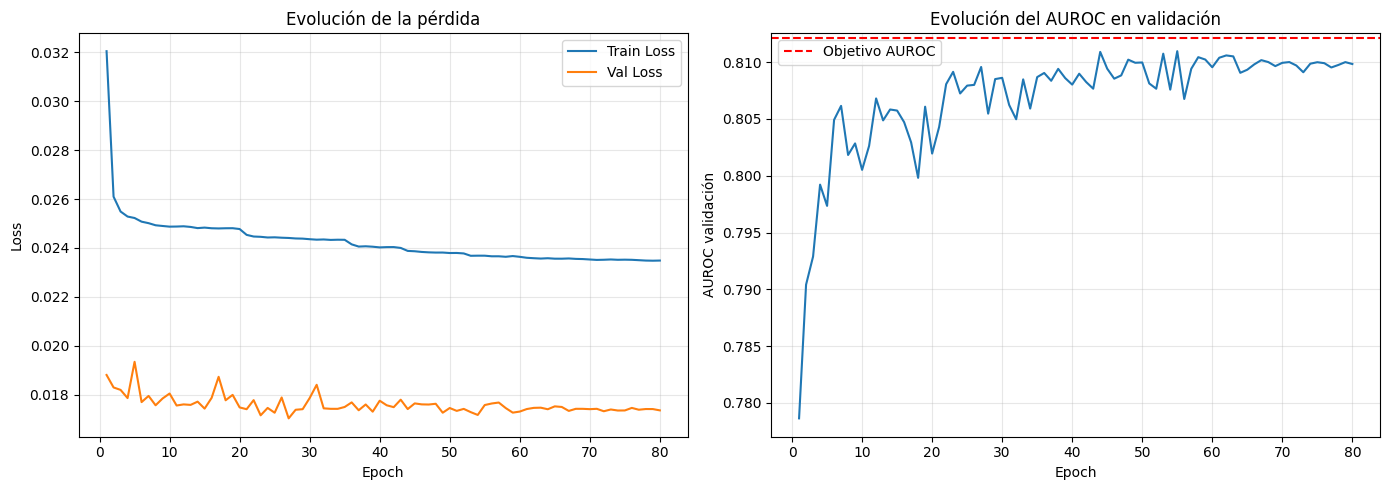

Curvas guardadas: ../results/training_curves.png


In [16]:
import matplotlib.pyplot as plt

# ── Curvas de entrenamiento ──────────────────────────────────────────────────
history = models[model_name]['history']
epochs_run = len(history['train_loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, epochs_run+1), history['train_loss'], label='Train Loss')
axes[0].plot(range(1, epochs_run+1), history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Evolución de la pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs_run+1), history['val_auroc'], color='#1f77b4')
axes[1].axhline(0.8121, color='r', linestyle='--', label='Objetivo AUROC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC validación')
axes[1].set_title('Evolución del AUROC en validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Curvas guardadas: {RESULTS_DIR}/training_curves.png')


In [17]:
def show_model_metrics_optimized(model, model_name, model_path, leads=None):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
    model.eval()

    test_probs, test_true = [], []
    with torch.no_grad():
        for X_b, y_b, len_b, sofa_b in test_loader:
            sepsis_logit, _ = model(X_b.to(DEVICE), len_b.to(DEVICE))
            test_probs.extend(torch.sigmoid(sepsis_logit).cpu().numpy())
            test_true.extend(y_b.numpy())

    test_probs = np.array(test_probs)
    test_true  = np.array(test_true)

    fpr, tpr, thresholds = roc_curve(test_true, test_probs)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    preds = (test_probs >= best_thresh).astype(int)

    auroc = roc_auc_score(test_true, test_probs)
    auprc = average_precision_score(test_true, test_probs)

    print(f'=== {model_name} (Umbral Opt: {best_thresh:.3f}) ===')
    print(f'AUROC: {auroc:.4f}  |  AUPRC: {auprc:.4f}')
    print(classification_report(test_true, preds, target_names=['No alerta', 'Alerta']))

    print('\n--- Curva de operacion clinica ---')
    for target_recall in [0.30, 0.50, 0.70]:
        eligible = np.where(tpr >= target_recall)[0]
        if len(eligible) == 0:
            print(f'  Recall >= {target_recall:.0%} → no alcanzable')
            continue
        i    = eligible[0]
        thr  = thresholds[i]
        sel  = test_probs >= thr
        prec = (sel & (test_true == 1)).sum() / max(sel.sum(), 1)
        print(f'  Recall >= {target_recall:.0%} → umbral={thr:.3f}  precision={prec:.3f}  recall_real={tpr[i]:.3f}')

    print('\n--- Precision @ top-k alertas ---')
    for top_pct in [0.01, 0.05, 0.10]:
        k      = max(int(len(test_probs) * top_pct), 1)
        top_k  = np.argsort(-test_probs)[:k]
        prec_k = test_true[top_k].mean()
        print(f'  Top {top_pct:.0%} ({k:,} alertas) → precision={prec_k:.3f}')

    prevalence = test_true.mean()
    print(f'\nPrevalencia test: {prevalence:.2%}  |  AUPRC lift: {auprc/prevalence:.2f}x')

    if leads is not None:
        leads_arr = np.array(leads)
        tp_mask = (test_true == 1) & (preds == 1) & ~np.isnan(leads_arr)
        fn_mask = (test_true == 1) & (preds == 0) & ~np.isnan(leads_arr)
        if tp_mask.any():
            print(f'\nTiempo de alerta (TP): {leads_arr[tp_mask].mean():.1f}h antes del onset '
                  f'(mediana: {np.median(leads_arr[tp_mask]):.1f}h)')
        print(f'Alarmas emitidas (TP): {tp_mask.sum():,} | Perdidas (FN): {fn_mask.sum():,}')

    return auroc, auprc

for model_name, values in models.items():
    show_model_metrics_optimized(
        model=values['model'],
        model_name=model_name,
        model_path=values['path'],
        leads=leads_test,
    )


=== best_lstm_multitask (Umbral Opt: 0.220) ===
AUROC: 0.8107  |  AUPRC: 0.2065
              precision    recall  f1-score   support

   No alerta       0.98      0.71      0.82    239768
      Alerta       0.12      0.76      0.20     12348

    accuracy                           0.71    252116
   macro avg       0.55      0.73      0.51    252116
weighted avg       0.94      0.71      0.79    252116


--- Curva de operacion clinica ---
  Recall >= 30% → umbral=0.331  precision=0.249  recall_real=0.300
  Recall >= 50% → umbral=0.285  precision=0.190  recall_real=0.500
  Recall >= 70% → umbral=0.235  precision=0.132  recall_real=0.700

--- Precision @ top-k alertas ---
  Top 1% (2,521 alertas) → precision=0.370
  Top 5% (12,605 alertas) → precision=0.263
  Top 10% (25,211 alertas) → precision=0.210

Prevalencia test: 4.90%  |  AUPRC lift: 4.22x

Tiempo de alerta (TP): 3.4h antes del onset (mediana: 3.0h)
Alarmas emitidas (TP): 9,401 | Perdidas (FN): 2,947


## XAI – Explicabilidad con SHAP

Interpretamos las predicciones del BiLSTM mediante valores SHAP (GradientExplainer) para identificar qué variables y momentos temporales impulsan cada alerta de sepsis.


In [18]:
import shap
print(f'SHAP version: {shap.__version__}')


SHAP version: 0.52.0


In [19]:
# ── Preparar datos de background y test para SHAP ────────────────────────────
# Tomamos una muestra representativa del test set
n_background = 50
n_test_shap = 30

# Indices aleatorios estratificados (positivos + negativos)
pos_idx = np.where(y_test == 1)[0]
neg_idx = np.where(y_test == 0)[0]

_rng = np.random.default_rng(RANDOM_STATE_SEED)
bg_pos = _rng.choice(pos_idx, size=min(20, len(pos_idx)), replace=False)
bg_neg = _rng.choice(neg_idx, size=min(30, len(neg_idx)), replace=False)
bg_idx = np.concatenate([bg_pos, bg_neg])

test_pos = _rng.choice(pos_idx, size=min(10, len(pos_idx)), replace=False)
test_neg = _rng.choice(neg_idx, size=min(20, len(neg_idx)), replace=False)
test_idx = np.concatenate([test_pos, test_neg])

X_bg = torch.from_numpy(X_test_norm[bg_idx]).float().to(DEVICE)
X_shap = torch.from_numpy(X_test_norm[test_idx]).float().to(DEVICE)
len_bg = torch.from_numpy(lens_test[bg_idx]).long().to(DEVICE)
len_shap = torch.from_numpy(lens_test[test_idx]).long().to(DEVICE)

print(f'Background: {X_bg.shape[0]} muestras')
print(f'Test SHAP:  {X_shap.shape[0]} muestras')


Background: 50 muestras
Test SHAP:  30 muestras


In [20]:
# ── Wrapper del modelo para SHAP ─────────────────────────────────────────────
# SHAP espera un modelo que reciba un tensor 2D (batch, features).
# Nuestro modelo recibe (batch, 24, 78) + lengths. Creamos un wrapper que
# reconstruye la forma original, pasa lengths y devuelve (batch, 1).

class ShapWrapper(torch.nn.Module):
    def __init__(self, base_model, lengths):
        super().__init__()
        self.model = base_model
        self.lengths = lengths
        self.T = 24
        self.F = 78

    def forward(self, x):
        # x llega como (batch, T*F) → reconstruir a (batch, T, F)
        if x.dim() == 2:
            x = x.view(-1, self.T, self.F)
        # Devolvemos (batch, 1) para que SHAP maneje correctamente la salida
        logit = self.model(x, self.lengths[:x.size(0)])[0]
        return logit.unsqueeze(1)

# Cargar modelo entrenado
lstm_shap = Bi_LSTM_Sepsis(input_size=N_INPUT).to(DEVICE)
lstm_shap.load_state_dict(torch.load(f'{MODELS_DIR}/best_lstm_multitask.pt',
                                      map_location=DEVICE, weights_only=True))
lstm_shap.eval()

wrapped_bg = ShapWrapper(lstm_shap, len_bg)
wrapped_shap = ShapWrapper(lstm_shap, len_shap)


In [21]:
# ── Calcular valores SHAP con GradientExplainer ─────────────────────────────
# GradientExplainer es mas eficiente y evita el IndexError / MemoryError
# que produce DeepExplainer con salidas 1D o backgrounds grandes.
X_bg_flat = X_bg.view(X_bg.size(0), -1)
X_shap_flat = X_shap.view(X_shap.size(0), -1)

explainer = shap.GradientExplainer(wrapped_bg, X_bg_flat)
wrapped_bg.train()  # LSTM/cuDNN requiere train mode para backward pass
shap_values = explainer.shap_values(X_shap_flat)

# GradientExplainer devuelve una lista de arrays (uno por salida).
# Como tenemos una sola salida (sepsis logit), tomamos el primer elemento.
if isinstance(shap_values, list):
    shap_values = shap_values[0]
print(f'Shape de SHAP values: {shap_values.shape}')


Shape de SHAP values: (30, 1872, 1)


In [22]:
# ── Reconstruir nombres de features por paso temporal ───────────────────────
# 78 features = 26 valores + 26 deltas + 26 máscaras
base_features = FEATURE_COLS
feature_names = []
for t in range(24):
    for f in base_features:
        feature_names.append(f'{f}_t{t}')
    for f in base_features:
        feature_names.append(f'delta_{f}_t{t}')
    for f in base_features:
        feature_names.append(f'mask_{f}_t{t}')

# Para visualización más clara, agrupamos por variable base promediando SHAP
shap_arr = np.squeeze(shap_values)  # elimina dim extra si existe
if shap_arr.ndim == 1:
    shap_arr = shap_arr[np.newaxis, :]

# Promedio absoluto de SHAP por variable base (ignorando hora)
shap_by_var = {}
for i, name in enumerate(feature_names):
    base_name = name.split('_t')[0].replace('delta_', '').replace('mask_', '')
    shap_by_var.setdefault(base_name, []).append(np.abs(shap_arr[:, i]))

var_importance = {k: np.mean(np.vstack(v), axis=1) for k, v in shap_by_var.items()}
importance_df = pd.DataFrame(var_importance).mean().sort_values(ascending=False)
print('Top 15 variables más importantes (media |SHAP|):')
print(importance_df.head(15).to_string())


Top 15 variables más importantes (media |SHAP|):
urine_output_ml                 0.000585
GCS - Verbal Response           0.000256
vasopressor_active              0.000252
pO2                             0.000245
GCS - Motor Response            0.000231
mechanical_ventilation          0.000204
Platelet Count                  0.000199
Heart Rate                      0.000197
pH                              0.000185
Glucose                         0.000155
Temperature Celsius             0.000155
Lactate                         0.000149
PEEP set                        0.000139
charlson_score                  0.000135
Arterial Blood Pressure mean    0.000133


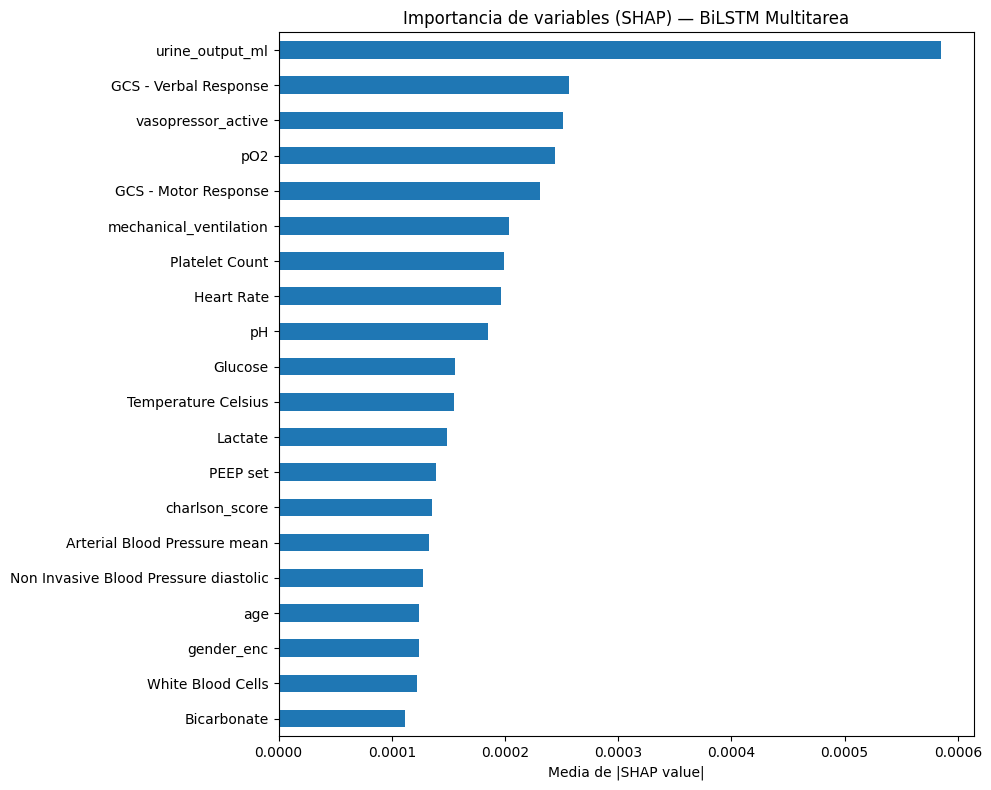

Figura guardada: ../results/shap_feature_importance.png


In [23]:
# ── Visualización: importancia global de variables ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
importance_df.head(20).plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_xlabel('Media de |SHAP value|')
ax.set_title('Importancia de variables (SHAP) — BiLSTM Multitarea')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {RESULTS_DIR}/shap_feature_importance.png')


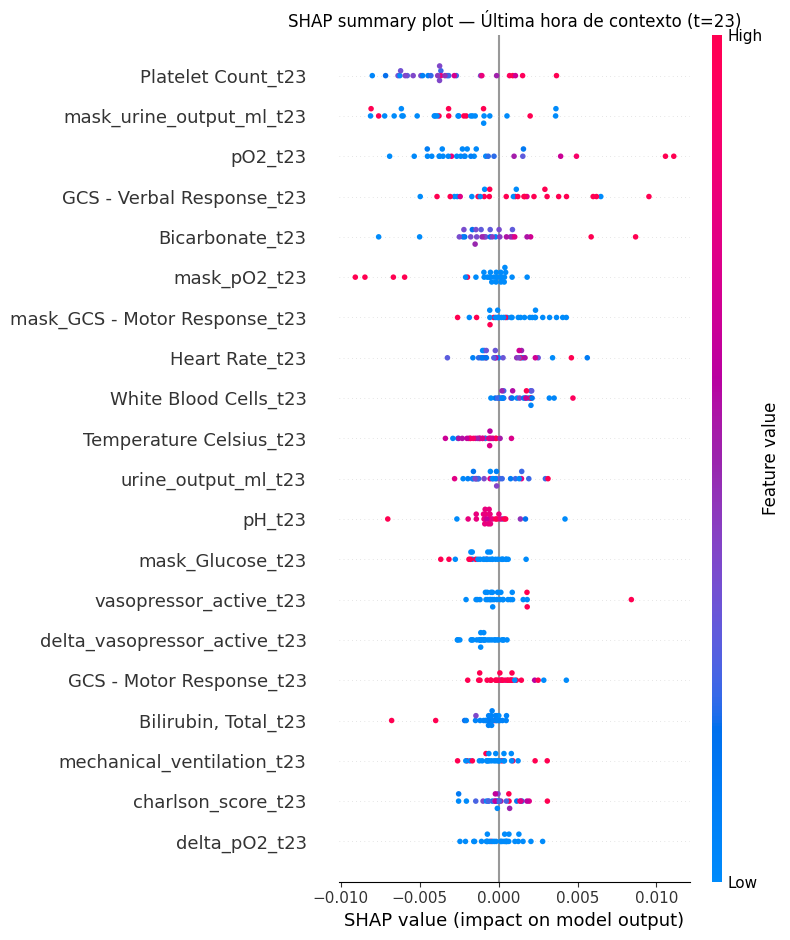

Figura guardada: ../results/shap_summary_plot.png


In [24]:
# ── Visualización: SHAP summary plot (beeswarm) ───────────────────────────────
# Para el summary plot usamos las 78 features del último timestep (más reciente)
# ya que representan el estado actual del paciente
recent_features = []
for f in base_features:
    recent_features.append(f'{f}_t23')
for f in base_features:
    recent_features.append(f'delta_{f}_t23')
for f in base_features:
    recent_features.append(f'mask_{f}_t23')

# Índices de las últimas 78 posiciones
idx_recent = list(range(24*78 - 78, 24*78))
shap_recent = shap_arr[:, idx_recent]
X_recent = X_shap_flat.cpu().numpy()[:, idx_recent]

fig, ax = plt.subplots(figsize=(10, 12))
shap.summary_plot(
    shap_recent, X_recent, feature_names=recent_features,
    show=False, max_display=20
)
plt.title('SHAP summary plot — Última hora de contexto (t=23)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {RESULTS_DIR}/shap_summary_plot.png')


In [25]:
# ── Ejemplo: explicación de una alerta individual (waterfall) ─────────────────
# Seleccionamos una muestra positiva con alta probabilidad para explicar
X_shap_flat = X_shap.view(X_shap.size(0), -1)
probs_shap = torch.sigmoid(wrapped_shap(X_shap_flat)).detach().cpu().numpy()
pos_high = np.where((y_test[test_idx] == 1) & (probs_shap[:, 0] > 0.6))[0]

# Valor base manualmente (GradientExplainer no expone expected_value directamente)
with torch.no_grad():
    base_value = float(torch.sigmoid(wrapped_bg(X_bg_flat)).mean().cpu())

if len(pos_high) > 0:
    idx_explain = pos_high[0]
    print(f'Explicando muestra {idx_explain} — Probabilidad: {probs_shap[idx_explain, 0]:.3f}')

    fig, ax = plt.subplots(figsize=(10, 14))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_arr[idx_explain],
            base_values=base_value,
            data=X_shap_flat.cpu().numpy()[idx_explain],
            feature_names=feature_names
        ), max_display=20, show=False
    )
    plt.title(f'SHAP waterfall — Caso de sepsis (prob={probs_shap[idx_explain, 0]:.3f})')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura guardada: {RESULTS_DIR}/shap_waterfall_example.png')
else:
    print('No se encontró caso positivo con probabilidad > 0.6 en la muestra.')


No se encontró caso positivo con probabilidad > 0.6 en la muestra.
